# Filtered Dataset Minifier

Builds a clean extract of the NASA GLOBE dataset by sampling images that pass the per-class `head2_conf` threshold from the filter CSV, spread randomly across the full confidence range rather than taken alphabetically.

Output: `resources/cloud-images/NASA_GLOBE_CD/extract_filtered/`

In [5]:
import pandas as pd
import shutil
from pathlib import Path
from collections import Counter

CSV_PATH    = Path("../resources/cloud-images/NASA_GLOBE_CD/cloud_filter_results_1.csv")
SOURCE_ROOT = Path("../resources/cloud-images/NASA_GLOBE_CD/downloaded_images")
DEST_DIR    = Path("../resources/cloud-images/NASA_GLOBE_CD/extract_filtered")

THRESHOLDS = {
    "Ac": 0.80,
    "As": 0.80,
    "Cb": 0.80,
    "Cc": 0.80,
    "Ci": 0.80,
    "Cs": 0.80,
    # "Ct": 0.0,
    "Cu": 0.80,
    "Ns": 0.80,
    "Sc": 0.80,
    "St": 0.80,
}
MAX_PER_CLASS = 7000

df = pd.read_csv(CSV_PATH)
df = df.rename(columns={"cloud_conf": "head2_conf", "head1_class": "head1_pred"})

print(f"CSV loaded: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")

CSV loaded: 467,620 rows
Columns: ['folder', 'filename', 'head2_conf', 'head2_pred', 'head1_pred', 'head1_conf']


In [6]:
# Select images: random sample across the full confidence range [threshold, 1.0]
selected = {}
for folder, thresh in THRESHOLDS.items():
    pool = df[(df["folder"] == folder) & (df["head2_conf"] >= thresh)]
    sample = pool.sample(min(MAX_PER_CLASS, len(pool)), random_state=42)
    selected[folder] = sample["filename"].tolist()
    print(f"  {folder:6s}  pool: {len(pool):,}  selected: {len(sample):,}  "
          f"conf range: [{pool['head2_conf'].min():.2f}, {pool['head2_conf'].max():.2f}]")

total = sum(len(v) for v in selected.values())
print(f"\n  TOTAL  {total:,}")

  Ac      pool: 22,492  selected: 7,000  conf range: [0.80, 1.00]
  As      pool: 23,702  selected: 7,000  conf range: [0.80, 1.00]
  Cb      pool: 7,328  selected: 7,000  conf range: [0.80, 1.00]
  Cc      pool: 11,874  selected: 7,000  conf range: [0.80, 1.00]
  Ci      pool: 25,859  selected: 7,000  conf range: [0.80, 1.00]
  Cs      pool: 19,024  selected: 7,000  conf range: [0.80, 1.00]
  Cu      pool: 89,465  selected: 7,000  conf range: [0.80, 1.00]
  Ns      pool: 19,141  selected: 7,000  conf range: [0.80, 1.00]
  Sc      pool: 45,618  selected: 7,000  conf range: [0.80, 1.00]
  St      pool: 18,730  selected: 7,000  conf range: [0.80, 1.00]

  TOTAL  70,000


In [7]:
# Copy selected images into dest directory
if DEST_DIR.exists():
    raise FileExistsError(
        f"{DEST_DIR} already exists. Delete it manually before re-running."
    )

DEST_DIR.mkdir(parents=True)

for folder, filenames in selected.items():
    (DEST_DIR / folder).mkdir()
    for filename in filenames:
        src = SOURCE_ROOT / folder / filename
        dst = DEST_DIR / folder / filename
        shutil.copy2(src, dst)
    print(f"  {folder:6s}  copied {len(filenames):,}")

print(f"\nDone. Output: {DEST_DIR}")

  Ac      copied 7,000
  As      copied 7,000
  Cb      copied 7,000
  Cc      copied 7,000
  Ci      copied 7,000
  Cs      copied 7,000
  Cu      copied 7,000
  Ns      copied 7,000
  Sc      copied 7,000
  St      copied 7,000

Done. Output: ../resources/cloud-images/NASA_GLOBE_CD/extract_filtered


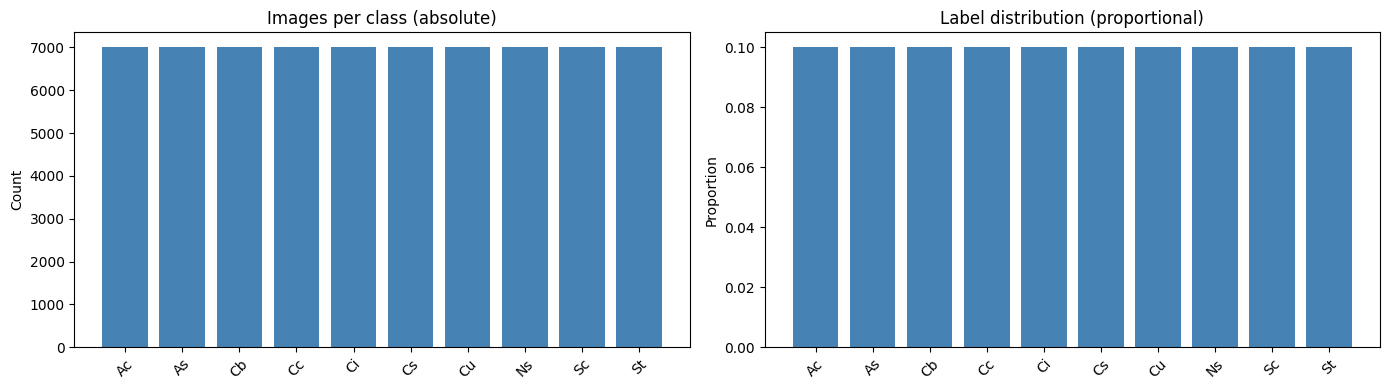

Total images on disk: 70,000


In [8]:
# Verify counts on disk
import numpy as np
import matplotlib.pyplot as plt

disk_counts = {}
for folder_dir in sorted(DEST_DIR.iterdir()):
    if folder_dir.is_dir():
        n = len(list(folder_dir.glob("*.jpg"))) + len(list(folder_dir.glob("*.png")))
        disk_counts[folder_dir.name] = n

classes = list(disk_counts.keys())
counts  = np.array(list(disk_counts.values()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(classes, counts, color="steelblue")
axes[0].set_ylabel("Count")
axes[0].set_title("Images per class (absolute)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(classes, counts / counts.sum(), color="steelblue")
axes[1].set_ylabel("Proportion")
axes[1].set_title("Label distribution (proportional)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Total images on disk: {counts.sum():,}")

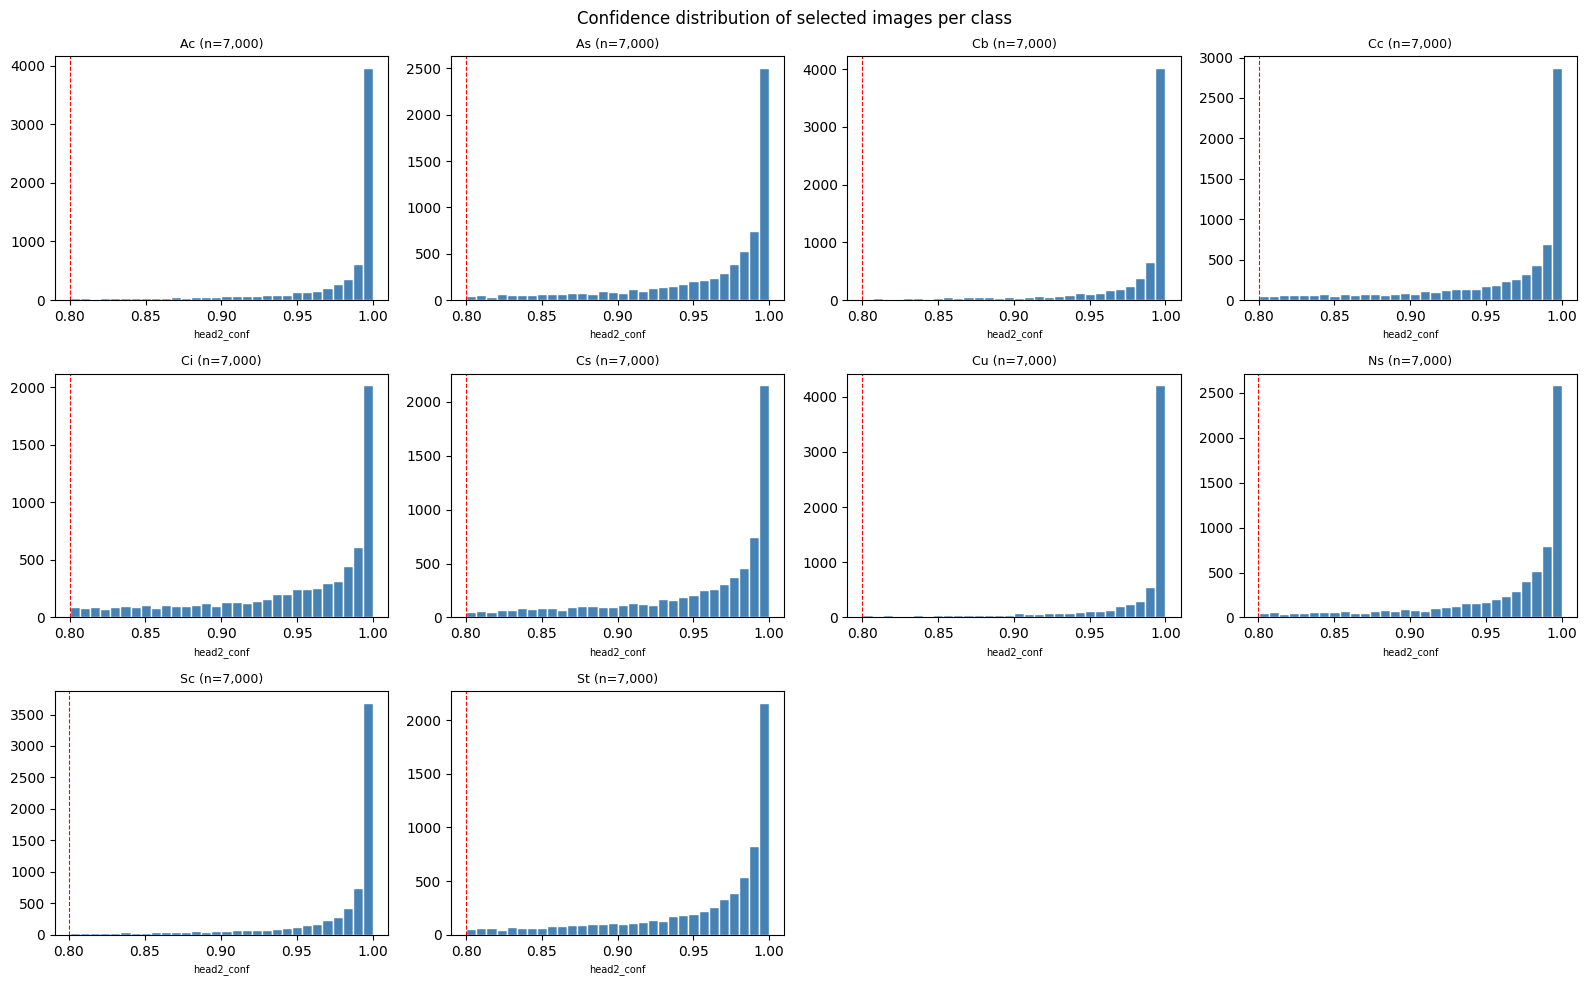

In [9]:
# Confidence distribution of selected images per class
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, (folder, thresh) in zip(axes.flat, THRESHOLDS.items()):
    pool = df[(df["folder"] == folder) & (df["head2_conf"] >= thresh)]
    sample_filenames = set(selected[folder])
    sample_df = pool[pool["filename"].isin(sample_filenames)]
    ax.hist(sample_df["head2_conf"], bins=30, color="steelblue", edgecolor="white")
    ax.axvline(thresh, color="red", linestyle="--", linewidth=0.8)
    ax.set_title(f"{folder} (n={len(sample_df):,})", fontsize=9)
    ax.set_xlabel("head2_conf", fontsize=7)

for ax in list(axes.flat)[len(THRESHOLDS):]:
    ax.axis("off")

plt.suptitle("Confidence distribution of selected images per class", fontsize=12)
plt.tight_layout()
plt.show()